# 04 - Model Training & Evaluation Experiments

In [ ]:
# 1. Imports and setup for Machine Learning experiments
# Import regression algorithms (Linear, Ridge, Random Forest, XGBoost) and evaluation metrics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: "%.3f" % x)

os.makedirs("../models", exist_ok=True)
print("ML modeling dependencies initialized.")


ML modeling dependencies initialized.


In [ ]:
# 2. Load processed ride features and perform Train/Test split
# We split 80% for training and 20% for testing.
ride_df = pd.read_csv("../data/processed/ride_features.csv")
print(f"Ride features dataset shape: {ride_df.shape}")

ride_feature_cols = [
    "distance", "surge_multiplier", "hour", "day_of_week", 
    "is_weekend", "is_rush_hour", "is_late_night", 
    "is_premium_tier", "is_shared"
]
X_ride = ride_df[ride_feature_cols]
y_ride = ride_df["price"]

X_ride_train, X_ride_test, y_ride_train, y_ride_test = train_test_split(
    X_ride, y_ride, test_size=0.20, random_state=42
)

print(f"Ride Train set: {X_ride_train.shape}, Test set: {X_ride_test.shape}")


Ride features dataset shape: (100000, 11)
Ride Train set: (80000, 9), Test set: (20000, 9)


In [ ]:
# 3. Train and benchmark candidate regression models for Ride Fare prediction
# Compare Linear Regression, Ridge, Random Forest, and XGBoost on MAE, RMSE, and R2 score.
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
}

ride_results = []
trained_ride_models = {}

for name, model in models.items():
    # Fit model on train data
    model.fit(X_ride_train, y_ride_train)
    trained_ride_models[name] = model
    
    # Predict on test data
    preds = model.predict(X_ride_test)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_ride_test, preds)
    rmse = root_mean_squared_error(y_ride_test, preds)
    r2 = r2_score(y_ride_test, preds)
    
    ride_results.append({
        "Model": name,
        "MAE ($)": mae,
        "RMSE ($)": rmse,
        "R2 Score": r2
    })

df_ride_results = pd.DataFrame(ride_results).sort_values("R2 Score", ascending=False)
display(df_ride_results)


,Model,MAE ($),RMSE ($),R2 Score
3,XGBoost Regressor,3.767,4.961,0.717
2,Random Forest,3.752,4.988,0.713
1,Ridge Regression,4.068,5.210,0.687
0,Linear Regression,4.068,5.210,0.687


/tmp/ipykernel_24345/2485330808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ride_results, x="Model", y="R2 Score", ax=axes[0], palette="Blues_d")


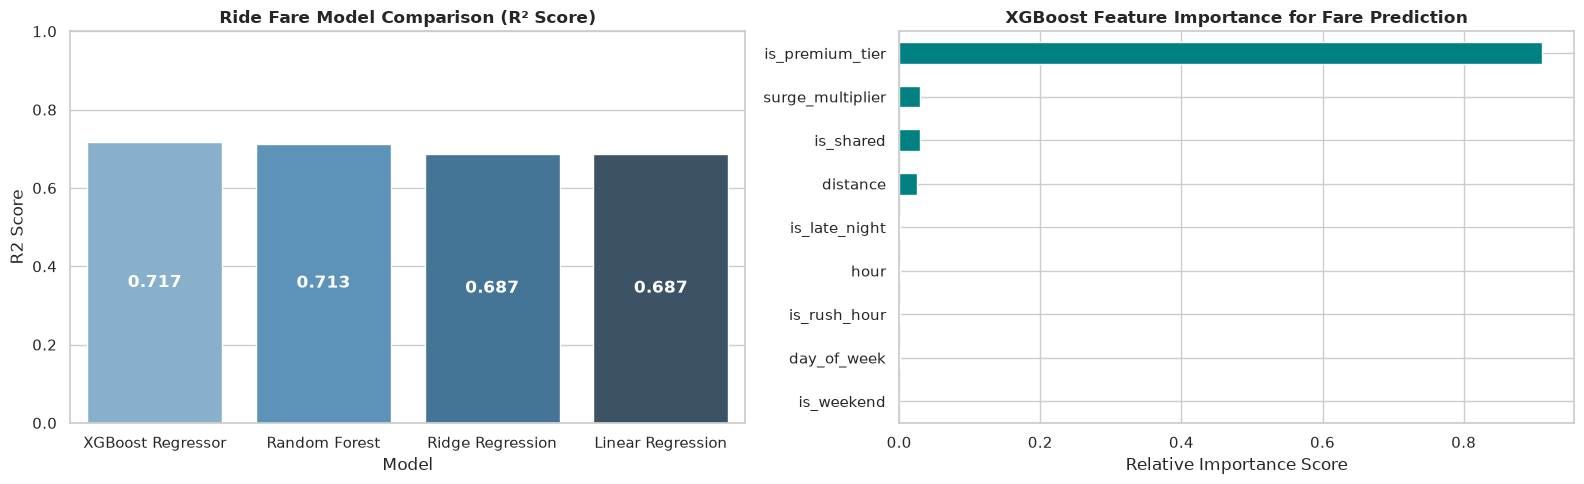

Saved best ride model artifact to ../models/ride_fare_xgb.joblib


In [ ]:
# 4. Model comparison visualization and XGBoost Feature Importance
# Visualize R2 metrics and identify key drivers of ride price (Distance, Tier, Surge).
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Model R2 comparison plot
sns.barplot(data=df_ride_results, x="Model", y="R2 Score", ax=axes[0], palette="Blues_d")
axes[0].set_title("Ride Fare Model Comparison (R² Score)", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# XGBoost feature importance plot
best_ride_model = trained_ride_models["XGBoost Regressor"]
importances = pd.Series(best_ride_model.feature_importances_, index=ride_feature_cols).sort_values(ascending=True)

importances.plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("XGBoost Feature Importance for Fare Prediction", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Relative Importance Score")

plt.tight_layout()
plt.show()

# Save best model artifact to disk
joblib.dump(best_ride_model, "../models/ride_fare_xgb.joblib")
print("Saved best ride model artifact to ../models/ride_fare_xgb.joblib")


In [ ]:
# 5. Train delivery delay and operational friction model
# We train an XGBoost regressor to predict operational delay given distance, weather, and traffic.
deliv_df = pd.read_csv("../data/processed/delivery_features.csv")
deliv_feature_cols = [
    "delivery_distance", "order_value", "traffic_severity", 
    "weather_severity", "is_small_basket", "is_long_distance", 
    "delivery_friction_index"
]

X_deliv = deliv_df[deliv_feature_cols]
y_deliv = deliv_df["delivery_delay"]

X_deliv_train, X_deliv_test, y_deliv_train, y_deliv_test = train_test_split(
    X_deliv, y_deliv, test_size=0.20, random_state=42
)

deliv_model = XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=5, random_state=42, n_jobs=-1)
deliv_model.fit(X_deliv_train, y_deliv_train)

deliv_preds = deliv_model.predict(X_deliv_test)
print(f"Delivery Model - MAE: {mean_absolute_error(y_deliv_test, deliv_preds):.3f} mins | R2: {r2_score(y_deliv_test, deliv_preds):.3f}")

joblib.dump(deliv_model, "../models/delivery_friction_xgb.joblib")
print("Saved best delivery model artifact to ../models/delivery_friction_xgb.joblib")


Delivery Model - MAE: 7.197 mins | R2: 0.050
Saved best delivery model artifact to ../models/delivery_friction_xgb.joblib


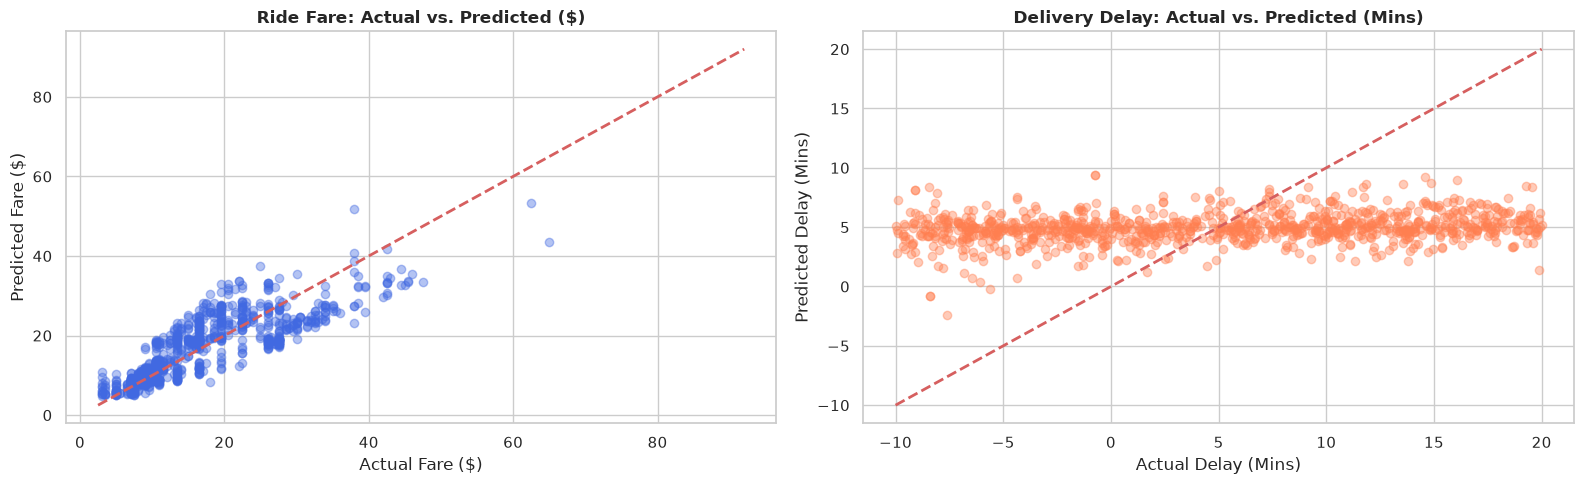

In [ ]:
# 6. Actual vs. Predicted Diagnostic Plots
# Confirm model calibration and linearity across test predictions.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ride Fare: Actual vs Predicted
axes[0].scatter(y_ride_test[:1000], best_ride_model.predict(X_ride_test[:1000]), alpha=0.4, color="royalblue")
axes[0].plot([y_ride_test.min(), y_ride_test.max()], [y_ride_test.min(), y_ride_test.max()], "r--", lw=2)
axes[0].set_title("Ride Fare: Actual vs. Predicted ($)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Actual Fare ($)")
axes[0].set_ylabel("Predicted Fare ($)")

# Delivery Delay: Actual vs Predicted
axes[1].scatter(y_deliv_test[:1000], deliv_preds[:1000], alpha=0.4, color="coral")
axes[1].plot([y_deliv_test.min(), y_deliv_test.max()], [y_deliv_test.min(), y_deliv_test.max()], "r--", lw=2)
axes[1].set_title("Delivery Delay: Actual vs. Predicted (Mins)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Actual Delay (Mins)")
axes[1].set_ylabel("Predicted Delay (Mins)")

plt.tight_layout()
plt.show()
